Loaded             : 15128 rows
Depth range        : -467.85 – 1687.37 m  (TVD_SS)
GR  range          : 14.39 – 661.23 API
PHIN range (clipped): 0.0000 – 1.9578
PHID range (clipped): 0.0000 – 0.5487

Depth window       : -467.85 – 1687.37 m
Rows after cut     : 15128

--- Effective Porosity Stats ---
  GR_min / GR_max : 50.62 / 261.09 API
  phi_Dsh         : 0.0523   phi_Nsh: 0.0155
  PHIE range      : 0.0000 – 1.3910

Results saved to   : effective_porosity_results_78B.csv
Plot saved to       : effective_porosity_58.png


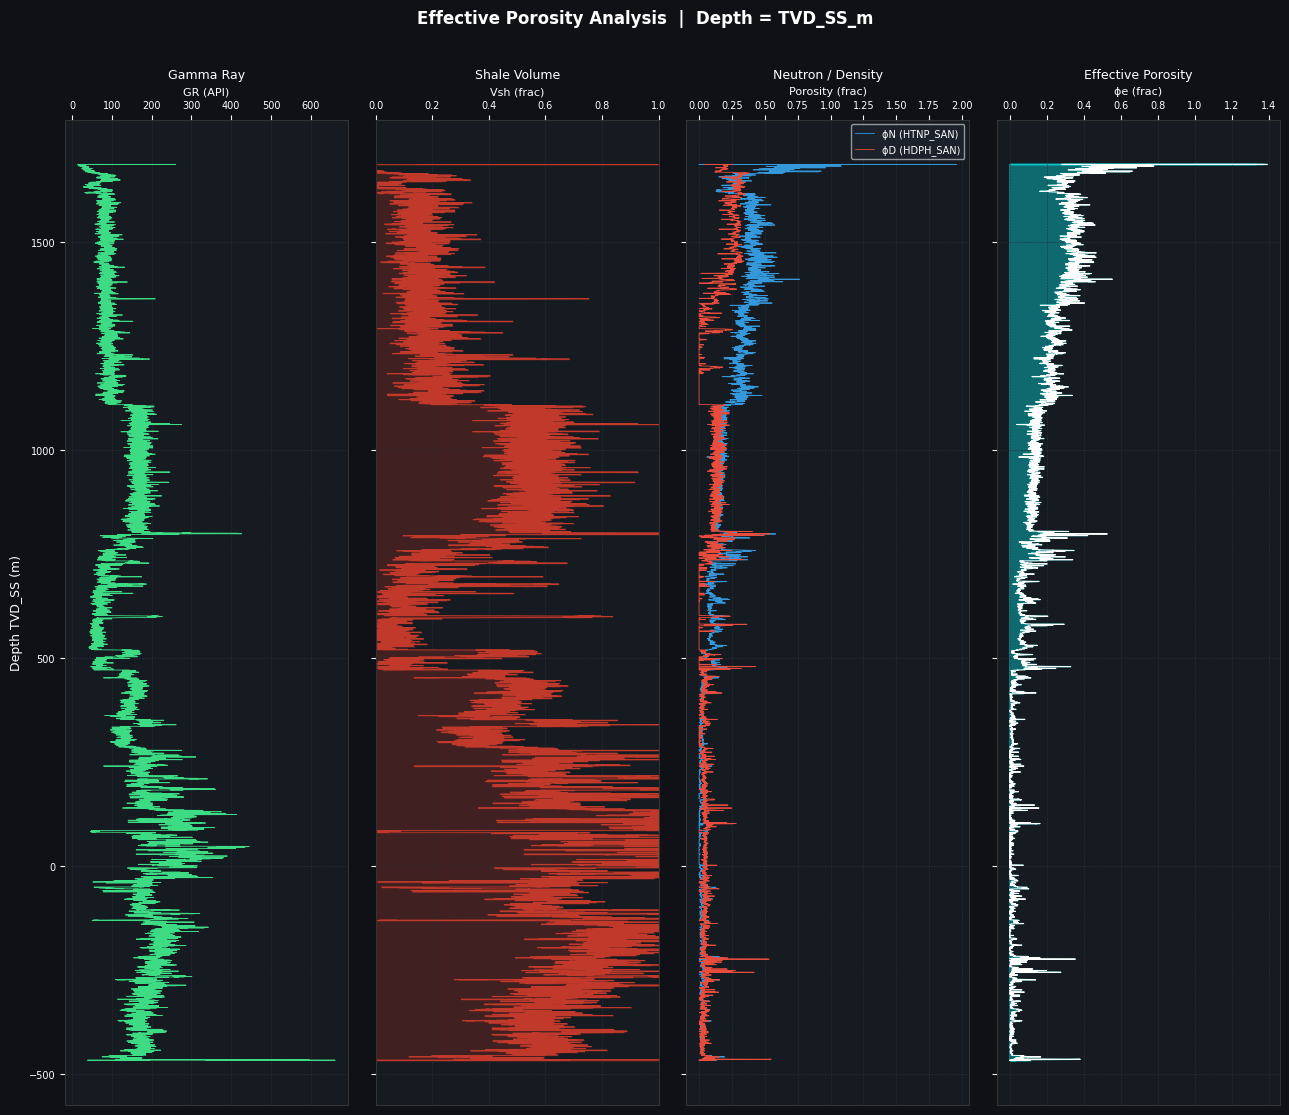

In [3]:
"""
Effective Porosity Calculation
==============================
Equations:
    V_sh      = (GR - GR_min) / (GR_max - GR_min)        # Shale volume (linear)
    phi_Dcorr = phi_D - (V_sh * phi_Dsh)                  # Shale-corrected density porosity
    phi_Ncorr = phi_N - (V_sh * phi_Nsh)                  # Shale-corrected neutron porosity
    phi_e     = sqrt( (phi_Dcorr^2 + phi_Ncorr^2) / 2 )  # Effective porosity

Input  : single CSV with columns:
         DEPTH_m, TVD_m, TVD_SS_m, NS_m, EW_m, HGR_STGC, HTNP_SAN, HDPH_SAN
Depth  : TVD_SS_m  (subsea TVD)
Mapping: GR = HGR_STGC  |  PHIN = HTNP_SAN  |  PHID = HDPH_SAN
Clipping: any porosity value < 0 is set to 0
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===========================================================================
# >>>  USER CONTROLS  <<<
# ===========================================================================
INPUT_FILE    = r"E:\Nova_2\env\1. EXPORT DATA LAS\OutputData_78B.csv"   # path to input CSV
DEPTH_MIN     = None                   # minimum TVD_SS_m (None = open)
DEPTH_MAX     = None                   # maximum TVD_SS_m (None = open)
INTERP_METHOD = "linear"               # "linear" or "cubic"
# ===========================================================================


# ---------------------------------------------------------------------------
# 1. Load & map columns
# ---------------------------------------------------------------------------
df_raw = pd.read_csv(INPUT_FILE, sep=",")

# Rename to internal names
df_raw = df_raw.rename(columns={
    "TVD_SS_m"  : "DEPTH",
    "HGR_STGC"  : "GR",
    "HTNP_SAN"  : "PHIN",
    "HDPH_SAN"  : "PHID",
})

# Keep only needed columns
df_raw = df_raw[["DEPTH", "GR", "PHIN", "PHID"]].copy()

# Clip porosity < 0 to 0
df_raw["PHIN"] = df_raw["PHIN"].clip(lower=0)
df_raw["PHID"] = df_raw["PHID"].clip(lower=0)

df_raw = df_raw.sort_values("DEPTH").reset_index(drop=True)

print(f"Loaded             : {len(df_raw)} rows")
print(f"Depth range        : {df_raw['DEPTH'].min():.2f} \u2013 {df_raw['DEPTH'].max():.2f} m  (TVD_SS)")
print(f"GR  range          : {df_raw['GR'].min():.2f} \u2013 {df_raw['GR'].max():.2f} API")
print(f"PHIN range (clipped): {df_raw['PHIN'].min():.4f} \u2013 {df_raw['PHIN'].max():.4f}")
print(f"PHID range (clipped): {df_raw['PHID'].min():.4f} \u2013 {df_raw['PHID'].max():.4f}")


# ---------------------------------------------------------------------------
# 2. Apply depth cut
# ---------------------------------------------------------------------------
depth_lo = DEPTH_MIN if DEPTH_MIN is not None else df_raw["DEPTH"].min()
depth_hi = DEPTH_MAX if DEPTH_MAX is not None else df_raw["DEPTH"].max()

df = (df_raw
      .loc[(df_raw["DEPTH"] >= depth_lo) & (df_raw["DEPTH"] <= depth_hi)]
      .reset_index(drop=True))

print(f"\nDepth window       : {depth_lo:.2f} \u2013 {depth_hi:.2f} m")
print(f"Rows after cut     : {len(df)}")


# ---------------------------------------------------------------------------
# 3. Compute effective porosity
# ---------------------------------------------------------------------------
GR_min = np.percentile(df["GR"], 5)
GR_max = np.percentile(df["GR"], 95)
df["VSH"] = ((df["GR"] - GR_min) / (GR_max - GR_min)).clip(0, 1)

shale_mask  = df["VSH"] >= df["VSH"].quantile(0.90)
phi_Dsh     = df.loc[shale_mask, "PHID"].mean()
phi_Nsh     = df.loc[shale_mask, "PHIN"].mean()

df["PHID_CORR"] = (df["PHID"] - df["VSH"] * phi_Dsh).clip(lower=0)
df["PHIN_CORR"] = (df["PHIN"] - df["VSH"] * phi_Nsh).clip(lower=0)
df["PHIE"]      = np.sqrt((df["PHID_CORR"]**2 + df["PHIN_CORR"]**2) / 2)

print(f"\n--- Effective Porosity Stats ---")
print(f"  GR_min / GR_max : {GR_min:.2f} / {GR_max:.2f} API")
print(f"  phi_Dsh         : {phi_Dsh:.4f}   phi_Nsh: {phi_Nsh:.4f}")
print(f"  PHIE range      : {df['PHIE'].min():.4f} \u2013 {df['PHIE'].max():.4f}")


# ---------------------------------------------------------------------------
# 4. Save results
# ---------------------------------------------------------------------------
out_csv = "effective_porosity_results_78B.csv"
df.to_csv(out_csv, index=False, sep=";")
print(f"\nResults saved to   : {out_csv}")


# ---------------------------------------------------------------------------
# 5. Plot — 4 tracks: GR | VSH | PHIN+PHID | PHIE
# ---------------------------------------------------------------------------
PANEL_BG   = "#161b22"
GRID_COLOR = "#2a2f3a"
TC         = "white"

fig, axes = plt.subplots(1, 4, figsize=(13, 11), sharey=True)
fig.patch.set_facecolor("#0f1117")

depth = df["DEPTH"]

# Track 1: GR
ax = axes[0]
ax.set_facecolor(PANEL_BG)
ax.plot(df["GR"], depth, color="#3ddc84", lw=0.6)
ax.set_xlabel("GR (API)", color=TC, fontsize=8)
ax.set_title("Gamma Ray", color=TC, fontsize=9)
ax.set_ylabel("Depth TVD_SS (m)", color=TC, fontsize=9)

# Track 2: VSH
ax = axes[1]
ax.set_facecolor(PANEL_BG)
ax.plot(df["VSH"], depth, color="#c0392b", lw=0.6)
ax.fill_betweenx(depth, 0, df["VSH"], color="#922b21", alpha=0.35)
ax.set_xlim(0, 1)
ax.set_xlabel("Vsh (frac)", color=TC, fontsize=8)
ax.set_title("Shale Volume", color=TC, fontsize=9)

# Track 3: PHIN + PHID
ax = axes[2]
ax.set_facecolor(PANEL_BG)
ax.plot(df["PHIN"], depth, color="#3498db", lw=0.6, label="\u03d5N (HTNP_SAN)")
ax.plot(df["PHID"], depth, color="#e74c3c", lw=0.6, label="\u03d5D (HDPH_SAN)")
ax.legend(fontsize=7, facecolor="#1e2530", labelcolor=TC, loc="upper right", framealpha=0.7)
ax.set_xlabel("Porosity (frac)", color=TC, fontsize=8)
ax.set_title("Neutron / Density", color=TC, fontsize=9)

# Track 4: PHIE
ax = axes[3]
ax.set_facecolor(PANEL_BG)
ax.plot(df["PHIE"], depth, color=TC, lw=0.7)
ax.fill_betweenx(depth, 0, df["PHIE"], color="cyan", alpha=0.35)
ax.set_xlabel("\u03d5e (frac)", color=TC, fontsize=8)
ax.set_title("Effective Porosity", color=TC, fontsize=9)

for ax in axes:
    ax.grid(True, color=GRID_COLOR, lw=0.4, linestyle="--")
    ax.tick_params(colors=TC, labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor("#333")
    ax.invert_yaxis()
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

fig.suptitle(
    "Effective Porosity Analysis  |  Depth = TVD_SS_m",
    color=TC, fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("effective_porosity_78B.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117", edgecolor="none")
print("Plot saved to       : effective_porosity_58.png")
plt.show()


Loaded             : 15128 rows
Depth range        : -467.85 – 1687.37 m  (TVD_SS)
Split depth        : 500.00 m
VSH method Zone A  : none
VSH method Zone B  : larionov_old

Zone A (TVD_SS ≤ split)  |  method: none  |  VSH = 0 (no shale correction)
  rows : 6798

Zone B (TVD_SS > split)  |  method: larionov_old
  GR_min : 35.16 API   GR_max : 181.42 API   rows : 8330
  VSH range : 0.000 – 0.990

Zone B shale end-points:  phi_Dsh=0.1338   phi_Nsh=0.1594

--- Effective Porosity Stats ---
  PHIE range : 0.0000 – 1.3910

Results saved to   : effective_porosity_split_58.csv
Plot saved to       : effective_porosity_split_58.png


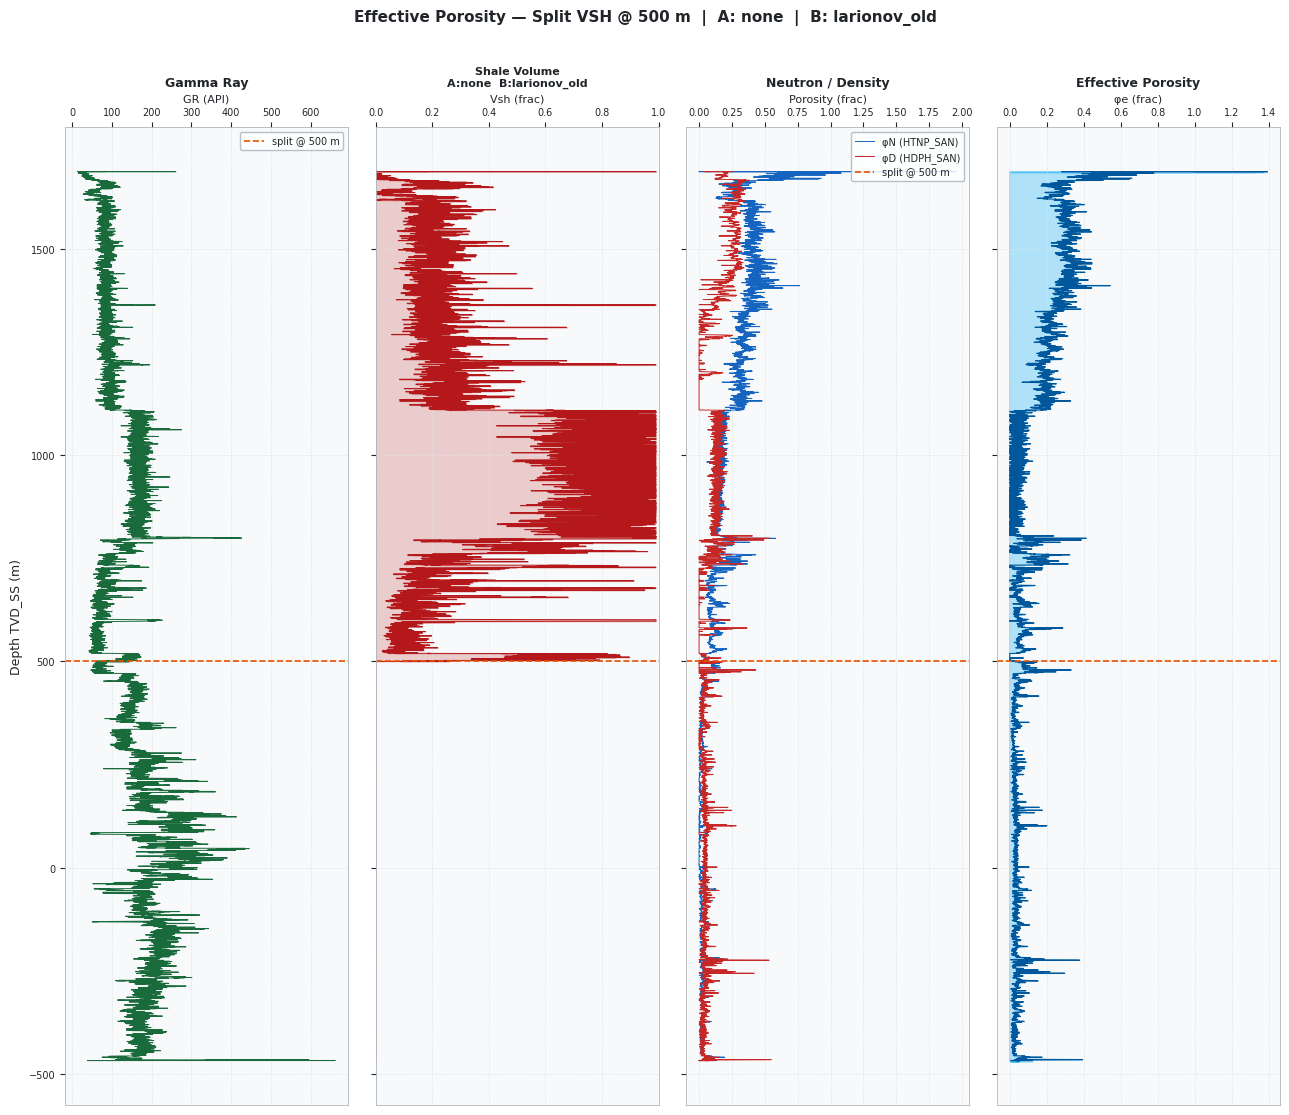

In [16]:
"""
Effective Porosity Calculation — Depth-Split VSH
=================================================
Input  : single CSV with columns:
         DEPTH_m, TVD_m, TVD_SS_m, NS_m, EW_m, HGR_STGC, HTNP_SAN, HDPH_SAN
Depth  : TVD_SS_m  (subsea TVD)
Mapping: GR = HGR_STGC  |  PHIN = HTNP_SAN  |  PHID = HDPH_SAN
Clipping: any porosity value < 0 is set to 0

VSH methods (set per zone):
    "linear"           : IGR  (always overestimates)
    "larionov_old"     : 0.33 * (2^(2*IGR) - 1)          older/consolidated rocks
    "larionov_tertiary": 0.083 * (2^(3.7*IGR) - 1)       young unconsolidated sands
    "steiber"          : IGR / (3 - 2*IGR)                conservative middle ground
    "clavier"          : 1.7 - sqrt(3.38 - (IGR+0.7)^2)  similar to larionov_old
    "none"             : VSH = 0  (no shale correction, e.g. metamorphic rock)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================================================================
# >>>  USER CONTROLS  <<<
# ===========================================================================
INPUT_FILE  = r"E:\Nova_2\env\1. EXPORT DATA LAS\OutputData_58.csv"   # path to input CSV
SPLIT_DEPTH = 500                 # TVD_SS_m split point (metres)
DEPTH_MIN   = None                   # minimum TVD_SS_m (None = open)
DEPTH_MAX   = None                   # maximum TVD_SS_m (None = open)

# VSH method per zone — set independently for Zone A and Zone B
VSH_METHOD_A = "none"       # Zone A  (TVD_SS <= SPLIT_DEPTH)
VSH_METHOD_B = "larionov_old"              # Zone B  (TVD_SS >  SPLIT_DEPTH)
# ===========================================================================


# ---------------------------------------------------------------------------
# Helper: compute VSH from IGR using chosen method
# ---------------------------------------------------------------------------
def igr_to_vsh(igr: np.ndarray, method: str) -> np.ndarray:
    """
    Convert linear IGR to VSH using the specified correction method.
    igr    : array of linear GR index values, already clipped to [0, 1]
    method : one of linear | larionov_old | larionov_tertiary | steiber | clavier | none
    """
    igr = np.asarray(igr, dtype=float)
    if method == "linear":
        return igr
    elif method == "larionov_old":
        return 0.33 * (2.0 ** (2.0 * igr) - 1.0)
    elif method == "larionov_tertiary":
        return 0.083 * (2.0 ** (3.7 * igr) - 1.0)
    elif method == "steiber":
        return igr / (3.0 - 2.0 * igr)
    elif method == "clavier":
        return 1.7 - np.sqrt(3.38 - (igr + 0.7) ** 2)
    elif method == "none":
        return np.zeros_like(igr)
    else:
        raise ValueError(f"Unknown VSH method: {repr(method)}. "
                         "Choose: linear | larionov_old | larionov_tertiary "
                         "| steiber | clavier | none")


# ---------------------------------------------------------------------------
# 1. Load & map columns
# ---------------------------------------------------------------------------
df_raw = pd.read_csv(INPUT_FILE, sep=",")

df_raw = df_raw.rename(columns={
    "TVD_SS_m"  : "DEPTH",
    "HGR"  : "GR",
    "HTNP_SAN"  : "PHIN",
    "DPHZ"  : "PHID",
})

df_raw = df_raw[["DEPTH", "GR", "PHIN", "PHID"]].copy()
df_raw["PHIN"] = df_raw["PHIN"].clip(lower=0)
df_raw["PHID"] = df_raw["PHID"].clip(lower=0)
df_raw = df_raw.sort_values("DEPTH").reset_index(drop=True)

depth_lo = DEPTH_MIN if DEPTH_MIN is not None else df_raw["DEPTH"].min()
depth_hi = DEPTH_MAX if DEPTH_MAX is not None else df_raw["DEPTH"].max()
df = (df_raw
      .loc[(df_raw["DEPTH"] >= depth_lo) & (df_raw["DEPTH"] <= depth_hi)]
      .reset_index(drop=True))

print(f"Loaded             : {len(df)} rows")
print(f"Depth range        : {df['DEPTH'].min():.2f} \u2013 {df['DEPTH'].max():.2f} m  (TVD_SS)")
print(f"Split depth        : {SPLIT_DEPTH:.2f} m")
print(f"VSH method Zone A  : {VSH_METHOD_A}")
print(f"VSH method Zone B  : {VSH_METHOD_B}")


# ---------------------------------------------------------------------------
# 2. Depth-split VSH
# ---------------------------------------------------------------------------
mask_shallow = df["DEPTH"] <= SPLIT_DEPTH
mask_deep    = df["DEPTH"] >  SPLIT_DEPTH

df["IGR"] = np.nan
df["VSH"] = np.nan

for label, mask, method in [
    ("Zone A (TVD_SS \u2264 split)", mask_shallow, VSH_METHOD_A),
    ("Zone B (TVD_SS > split)",  mask_deep,    VSH_METHOD_B),
]:
    if mask.sum() == 0:
        print(f"  \u26a0 {label}: no rows \u2013 skipped")
        continue

    if method == "none":
        df.loc[mask, "IGR"] = 0.0
        df.loc[mask, "VSH"] = 0.0
        print(f"\n{label}  |  method: none  |  VSH = 0 (no shale correction)")
        print(f"  rows : {mask.sum()}")
    else:
        gr_zone = df.loc[mask, "GR"]
        GR_min  = np.percentile(gr_zone, 5)
        GR_max  = np.percentile(gr_zone, 95)
        igr     = ((gr_zone - GR_min) / (GR_max - GR_min)).clip(0, 1).values
        vsh     = igr_to_vsh(igr, method).clip(0, 1)
        df.loc[mask, "IGR"] = igr
        df.loc[mask, "VSH"] = vsh
        print(f"\n{label}  |  method: {method}")
        print(f"  GR_min : {GR_min:.2f} API   GR_max : {GR_max:.2f} API   rows : {mask.sum()}")
        print(f"  VSH range : {vsh.min():.3f} \u2013 {vsh.max():.3f}")


# ---------------------------------------------------------------------------
# 3. Shale end-points — split by zone, skipped where method = "none"
# ---------------------------------------------------------------------------
df["phi_Dsh_used"] = np.nan
df["phi_Nsh_used"] = np.nan

for label, mask, method in [
    ("Zone A", mask_shallow, VSH_METHOD_A),
    ("Zone B", mask_deep,    VSH_METHOD_B),
]:
    if mask.sum() == 0:
        continue
    if method == "none":
        df.loc[mask, "phi_Dsh_used"] = 0.0
        df.loc[mask, "phi_Nsh_used"] = 0.0
        continue
    zone_df    = df[mask]
    shale_mask = zone_df["VSH"] >= zone_df["VSH"].quantile(0.90)
    phi_Dsh    = zone_df.loc[shale_mask, "PHID"].mean()
    phi_Nsh    = zone_df.loc[shale_mask, "PHIN"].mean()
    df.loc[mask, "phi_Dsh_used"] = phi_Dsh
    df.loc[mask, "phi_Nsh_used"] = phi_Nsh
    print(f"\n{label} shale end-points:  phi_Dsh={phi_Dsh:.4f}   phi_Nsh={phi_Nsh:.4f}")


# ---------------------------------------------------------------------------
# 4. Effective porosity
# ---------------------------------------------------------------------------
df["PHID_CORR"] = (df["PHID"] - df["VSH"] * df["phi_Dsh_used"]).clip(lower=0)
df["PHIN_CORR"] = (df["PHIN"] - df["VSH"] * df["phi_Nsh_used"]).clip(lower=0)
df["PHIE"]      = np.sqrt((df["PHID_CORR"]**2 + df["PHIN_CORR"]**2) / 2)

print(f"\n--- Effective Porosity Stats ---")
print(f"  PHIE range : {df['PHIE'].min():.4f} \u2013 {df['PHIE'].max():.4f}")


# ---------------------------------------------------------------------------
# 5. Save results
# ---------------------------------------------------------------------------
out_csv = "effective_porosity_split_58.csv"
df.to_csv(out_csv, index=False, sep=";")
print(f"\nResults saved to   : {out_csv}")


# ---------------------------------------------------------------------------
# 6. Plot — 4 tracks: GR | VSH | PHIN+PHID | PHIE  (dark theme)
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# 6. Plot — 4 tracks: GR | VSH | PHIN+PHID | PHIE  (light/white theme)
# ---------------------------------------------------------------------------
PANEL_BG    = "#f8f9fa"       # abu muda sangat terang — bukan pure white agar mata tidak lelah
GRID_COLOR  = "#dee2e6"       # abu grid lembut
SPINE_COLOR = "#adb5bd"       # warna tepi panel
TC          = "#212529"       # teks utama — hitam gelap
TC_MUTED    = "#6c757d"       # teks sekunder
SPLIT_COLOR = "#E65100"       # oranye gelap — kontras di background terang

fig, axes = plt.subplots(1, 4, figsize=(13, 11), sharey=True)
fig.patch.set_facecolor("white")

depth = df["DEPTH"]

def add_split_line(ax):
    ax.axhline(SPLIT_DEPTH, color=SPLIT_COLOR, lw=1.2, ls="--",
               label=f"split @ {SPLIT_DEPTH:.0f} m")

# Track 1: GR
ax = axes[0]
ax.set_facecolor(PANEL_BG)
ax.plot(df["GR"], depth, color="#1a6b3c", lw=0.7)
add_split_line(ax)
ax.legend(fontsize=7, facecolor="white", edgecolor=SPINE_COLOR,
          labelcolor=TC, loc="upper right", framealpha=0.85)
ax.set_xlabel("GR (API)", color=TC, fontsize=8)
ax.set_title("Gamma Ray", color=TC, fontsize=9, fontweight="bold")
ax.set_ylabel("Depth TVD_SS (m)", color=TC, fontsize=9)

# Track 2: VSH  (annotate method per zone)
ax = axes[1]
ax.set_facecolor(PANEL_BG)
ax.plot(df["VSH"], depth, color="#b5181a", lw=0.7)
ax.fill_betweenx(depth, 0, df["VSH"], color="#b5181a", alpha=0.20)
add_split_line(ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Vsh (frac)", color=TC, fontsize=8)
ax.set_title(
    f"Shale Volume\nA:{VSH_METHOD_A}  B:{VSH_METHOD_B}",
    color=TC, fontsize=8, fontweight="bold"
)

# Track 3: PHIN + PHID
ax = axes[2]
ax.set_facecolor(PANEL_BG)
ax.plot(df["PHIN"], depth, color="#1565C0", lw=0.7, label="φN (HTNP_SAN)")
ax.plot(df["PHID"], depth, color="#c62828", lw=0.7, label="φD (HDPH_SAN)")
add_split_line(ax)
ax.legend(fontsize=7, facecolor="white", edgecolor=SPINE_COLOR,
          labelcolor=TC, loc="upper right", framealpha=0.85)
ax.set_xlabel("Porosity (frac)", color=TC, fontsize=8)
ax.set_title("Neutron / Density", color=TC, fontsize=9, fontweight="bold")

# Track 4: PHIE
ax = axes[3]
ax.set_facecolor(PANEL_BG)
ax.plot(df["PHIE"], depth, color="#01579B", lw=0.8)
ax.fill_betweenx(depth, 0, df["PHIE"], color="#29B6F6", alpha=0.35)
add_split_line(ax)
ax.set_xlabel("φe (frac)", color=TC, fontsize=8)
ax.set_title("Effective Porosity", color=TC, fontsize=9, fontweight="bold")

for ax in axes:
    ax.set_facecolor(PANEL_BG)
    ax.grid(True, color=GRID_COLOR, lw=0.5, linestyle="--", alpha=0.8)
    ax.tick_params(colors=TC, labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.6)
    ax.invert_yaxis()
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

fig.suptitle(
    f"Effective Porosity — Split VSH @ {SPLIT_DEPTH:.0f} m  "
    f"|  A: {VSH_METHOD_A}  |  B: {VSH_METHOD_B}",
    color=TC, fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("effective_porosity_split_58.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
print("Plot saved to       : effective_porosity_split_58.png")
plt.show()